# Bibliotekos

In [87]:
import pandas as pd
import numpy as np
import torch
torch.cuda.is_available()
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from skorch import NeuralNetRegressor
from skorch.callbacks import Checkpoint, EarlyStopping
from skorch.dataset import ValidSplit

from pyts.decomposition import SingularSpectrumAnalysis

from Lasso2 import select_features_lasso

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.base import BaseEstimator, RegressorMixin
from skorch import NeuralNetRegressor

from sklearn.metrics import make_scorer, root_mean_squared_error

# Duomenų paruošimas

In [2]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")

data['observationTime'] = pd.to_datetime(data['observationTime'])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

lag_config = {
    'H2O_column_number_density': [1],
    'NO2_column_number_density': [1, 2, 3],
    'nmvoc': [1],
    'nh3': [1, 2, 11],
    'pm10': [1],
    'pans': [10],
    'dust': [1],
    'NO2': np.arange(1, 10, 1)
}

for feature, lags in lag_config.items():
    for lag in lags:
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# data['target'] = data['missforest_precipitation'].shift(-1)
data = data.dropna()

drop_names = [
    'observationTime',
    # 'absorbing_aerosol_index',
    # 'NO2_column_number_density',
    # 'stratospheric_NO2_column_number_density',
    # 'NO2_slant_column_number_density',
    # 'tropopause_pressure',
    # 'H2O_column_number_density',
    # 'BrO',
    # 'BrO_Error',
    # 'NO2',
    # 'NO2_Error',
    # 'O3',
    # 'O3_Error',
    # 'pm10',
    # 'pm2p5',
    # 'sia',
    # 'nmvoc',
    # 'dust',
    # 'nh3',
    # 'pans',
    # 'tp',
    # 't2m',
    # 'airTemperature',
    # 'seaLevelPressure',
    # 'relativeHumidity',
    # 'missforest_precipitation',
    # 'xgb_cloudCover',
    # 'feelsLikeTemperature_fixed',
    # 'windSpeed_fixed',
    # 'windGust_fixed',
    # 'windDirection_fixed',
    # 'month_cos',
    # 'month_sin',
    # 'month',
    # 'day_of_year'
]

# X = data.drop(columns=drop_names)
X = data
# y = data['target']

In [3]:
X.head()

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,...,dust_lag1,NO2_lag1,NO2_lag2,NO2_lag3,NO2_lag4,NO2_lag5,NO2_lag6,NO2_lag7,NO2_lag8,NO2_lag9
11,2018-07-12,-1.259574,0.000091,0.000061,0.000205,19223.746,2092.265400,1.413290e+13,1.937367e+13,3.779792e+15,...,0.042530,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15,3.959891e+15,4.149200e+15,4.526218e+15
12,2018-07-13,-1.214123,0.000084,0.000065,0.000208,19219.334,2178.943600,3.610126e+13,1.652258e+13,3.688520e+15,...,0.006774,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15,3.959891e+15,4.149200e+15
13,2018-07-14,-0.762476,0.000079,0.000063,0.000203,19222.883,2346.339133,3.659979e+13,1.520030e+13,4.186392e+15,...,0.011105,3.688520e+15,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15,3.959891e+15
14,2018-07-15,-1.098520,0.000090,0.000057,0.000149,16677.404,2322.217746,3.449885e+13,1.453966e+13,3.940498e+15,...,0.017107,4.186392e+15,3.688520e+15,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15,3.959520e+15
15,2018-07-16,-0.770874,0.000077,0.000062,0.000183,16673.053,2747.987500,3.512158e+13,1.647380e+13,3.581072e+15,...,0.037638,3.940498e+15,4.186392e+15,3.688520e+15,3.779792e+15,3.785389e+15,3.663516e+15,3.898540e+15,4.667088e+15,4.203628e+15


# SSA

In [4]:
# series = data['missforest_precipitation'].apply(lambda x: math.log(x+1)).values
series = np.log1p(data['missforest_precipitation'].values)

L = 120
n_comp = 120

ssa = SingularSpectrumAnalysis(window_size=L, lower_frequency_bound=0.1)

X_ssa = series.reshape(1, -1)
series_reshaped = series.reshape(1, -1)
all_components = ssa.fit_transform(series_reshaped)

# all_components forma po fit_transform yra (1, L, len(series))
# Ištraukiame tik komponentes:
components = all_components[0]

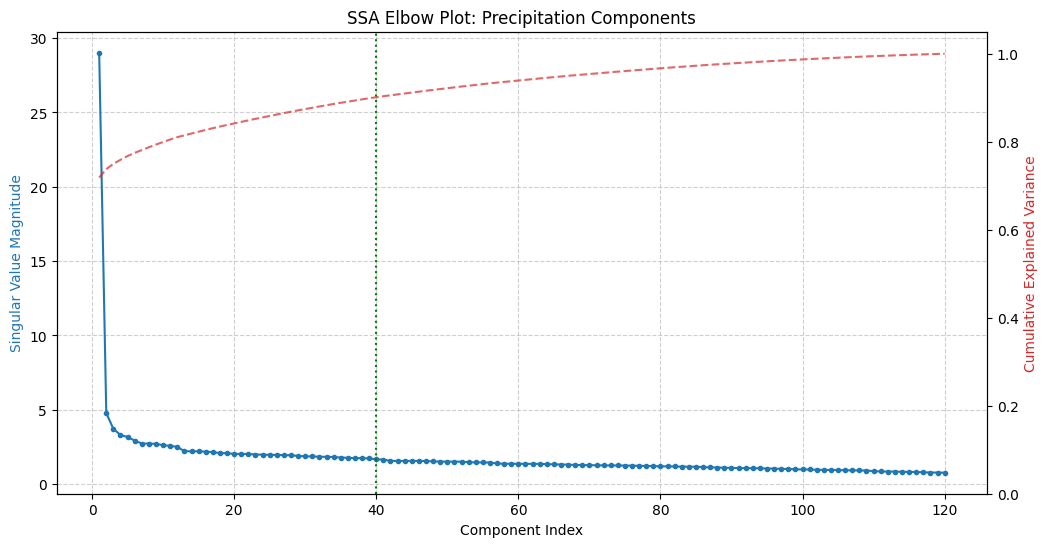

In [5]:
component_energies = np.array([np.sum(c**2) for c in components])
singular_values = np.sqrt(component_energies)

# 2. Sort them (SSA components are usually already sorted)
idx = np.argsort(singular_values)[::-1]
singular_values = singular_values[idx]

# 3. Calculate Variance Explained
total_var = np.sum(singular_values**2)
explained_variance = (singular_values**2) / total_var
cumulative_variance = np.cumsum(explained_variance)

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Singular Values (The Elbow)
ax1.plot(range(1, L + 1), singular_values, marker='o', markersize=3, color='tab:blue', label='Singular Values')
ax1.set_xlabel('Component Index')
ax1.set_ylabel('Singular Value Magnitude', color='tab:blue')
ax1.set_title('SSA Elbow Plot: Precipitation Components')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Cumulative Variance (To see how much info you keep)
ax2 = ax1.twinx()
ax2.plot(range(1, L + 1), cumulative_variance, color='tab:red', linestyle='--', alpha=0.7, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.set_ylim(0, 1.05)

# Add a vertical line at a suggested cutoff (e.g., where 90% variance is reached)
cutoff_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
ax1.axvline(x=cutoff_90, color='green', linestyle=':', label=f'90% Var ({cutoff_90} comps)')

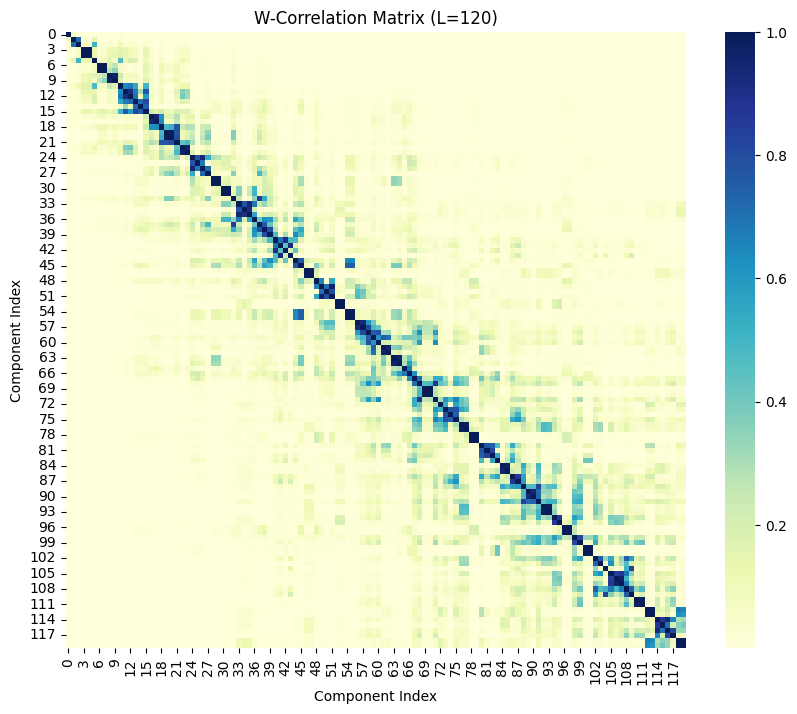

In [6]:
def plot_w_correlation(components):
    L, N = components.shape
    # Define the weights (w_i)
    # This reflects how many times each observation was used in the trajectory matrix
    K = N - L + 1
    w = np.array([min(i + 1, L, N - i) for i in range(N)])
    
    w_corr = np.zeros((L, L))
    
    # Calculate weighted norms once for efficiency
    weighted_norms = [np.sqrt(np.sum(w * (c**2))) for c in components]
    
    for i in range(L):
        for j in range(i, L):
            numerator = np.sum(w * components[i] * components[j])
            denominator = weighted_norms[i] * weighted_norms[j]
            val = abs(numerator / denominator)
            w_corr[i, j] = val
            w_corr[j, i] = val # Matrix is symmetric
            
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(w_corr, cmap='YlGnBu', annot=False)
    plt.title(f'W-Correlation Matrix (L={L})')
    plt.xlabel('Component Index')
    plt.ylabel('Component Index')
    plt.show()
    
    return w_corr

# Use it on your first 20-30 components (plotting 365 is too dense to read)
w_matrix = plot_w_correlation(components[:120])

C:\Users\crist\AppData\Local\Temp\ipykernel_46308\1079277040.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


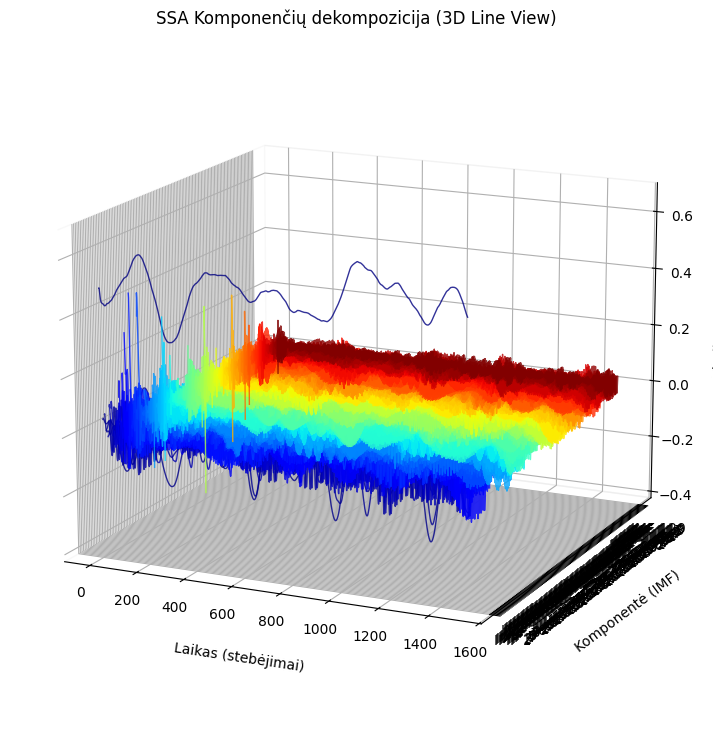

In [7]:
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')
# Nustatome segmentą vizualizacijai (pvz., pirmos 1500 valandų)
n_points = min(1500, len(series))
x = np.arange(n_points)
zs = np.arange(n_comp)

# Spalvų paletė
colors = plt.cm.jet(np.linspace(0, 1, n_comp))

for i in range(n_comp):
    y = components[i][:n_points]
    # Kiekvieną komponentę nubraižome kaip liniją tam tikrame gylio (z) lygmenyje
    # Naudojame plot() funkciją, kur y ašis (gylis) yra konstanta 'i'
    ax.plot(x, [i] * n_points, y, color=colors[i], linewidth=1, alpha=0.8)

# 3. Estetika ir kampas (kad būtų kaip image_4a4242.jpg)
ax.set_xlabel('Laikas (stebėjimai)', labelpad=15)
ax.set_ylabel('Komponentė (IMF)', labelpad=15)
ax.set_zlabel('Krituliai (mm)', labelpad=10)

# Kameros nustatymai: 
# elev (aukštis virš horizonto) - mažesnis skaičius žiūri labiau iš priekio
# azim (pasukimas aplink Z ašį) - nustatykite pagal tai, kiek "šono" norite matyti
ax.view_init(elev=15, azim=-65) 

# Nuimame pilką foną, kad būtų švariau (panašiai kaip pavyzdyje)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Nustatome y ašies žymas (komponenčių numerius)
ax.set_yticks(zs)
ax.set_yticklabels([f'IMF {i+1}' for i in zs])

plt.title("SSA Komponenčių dekompozicija (3D Line View)")
plt.tight_layout()
plt.show()

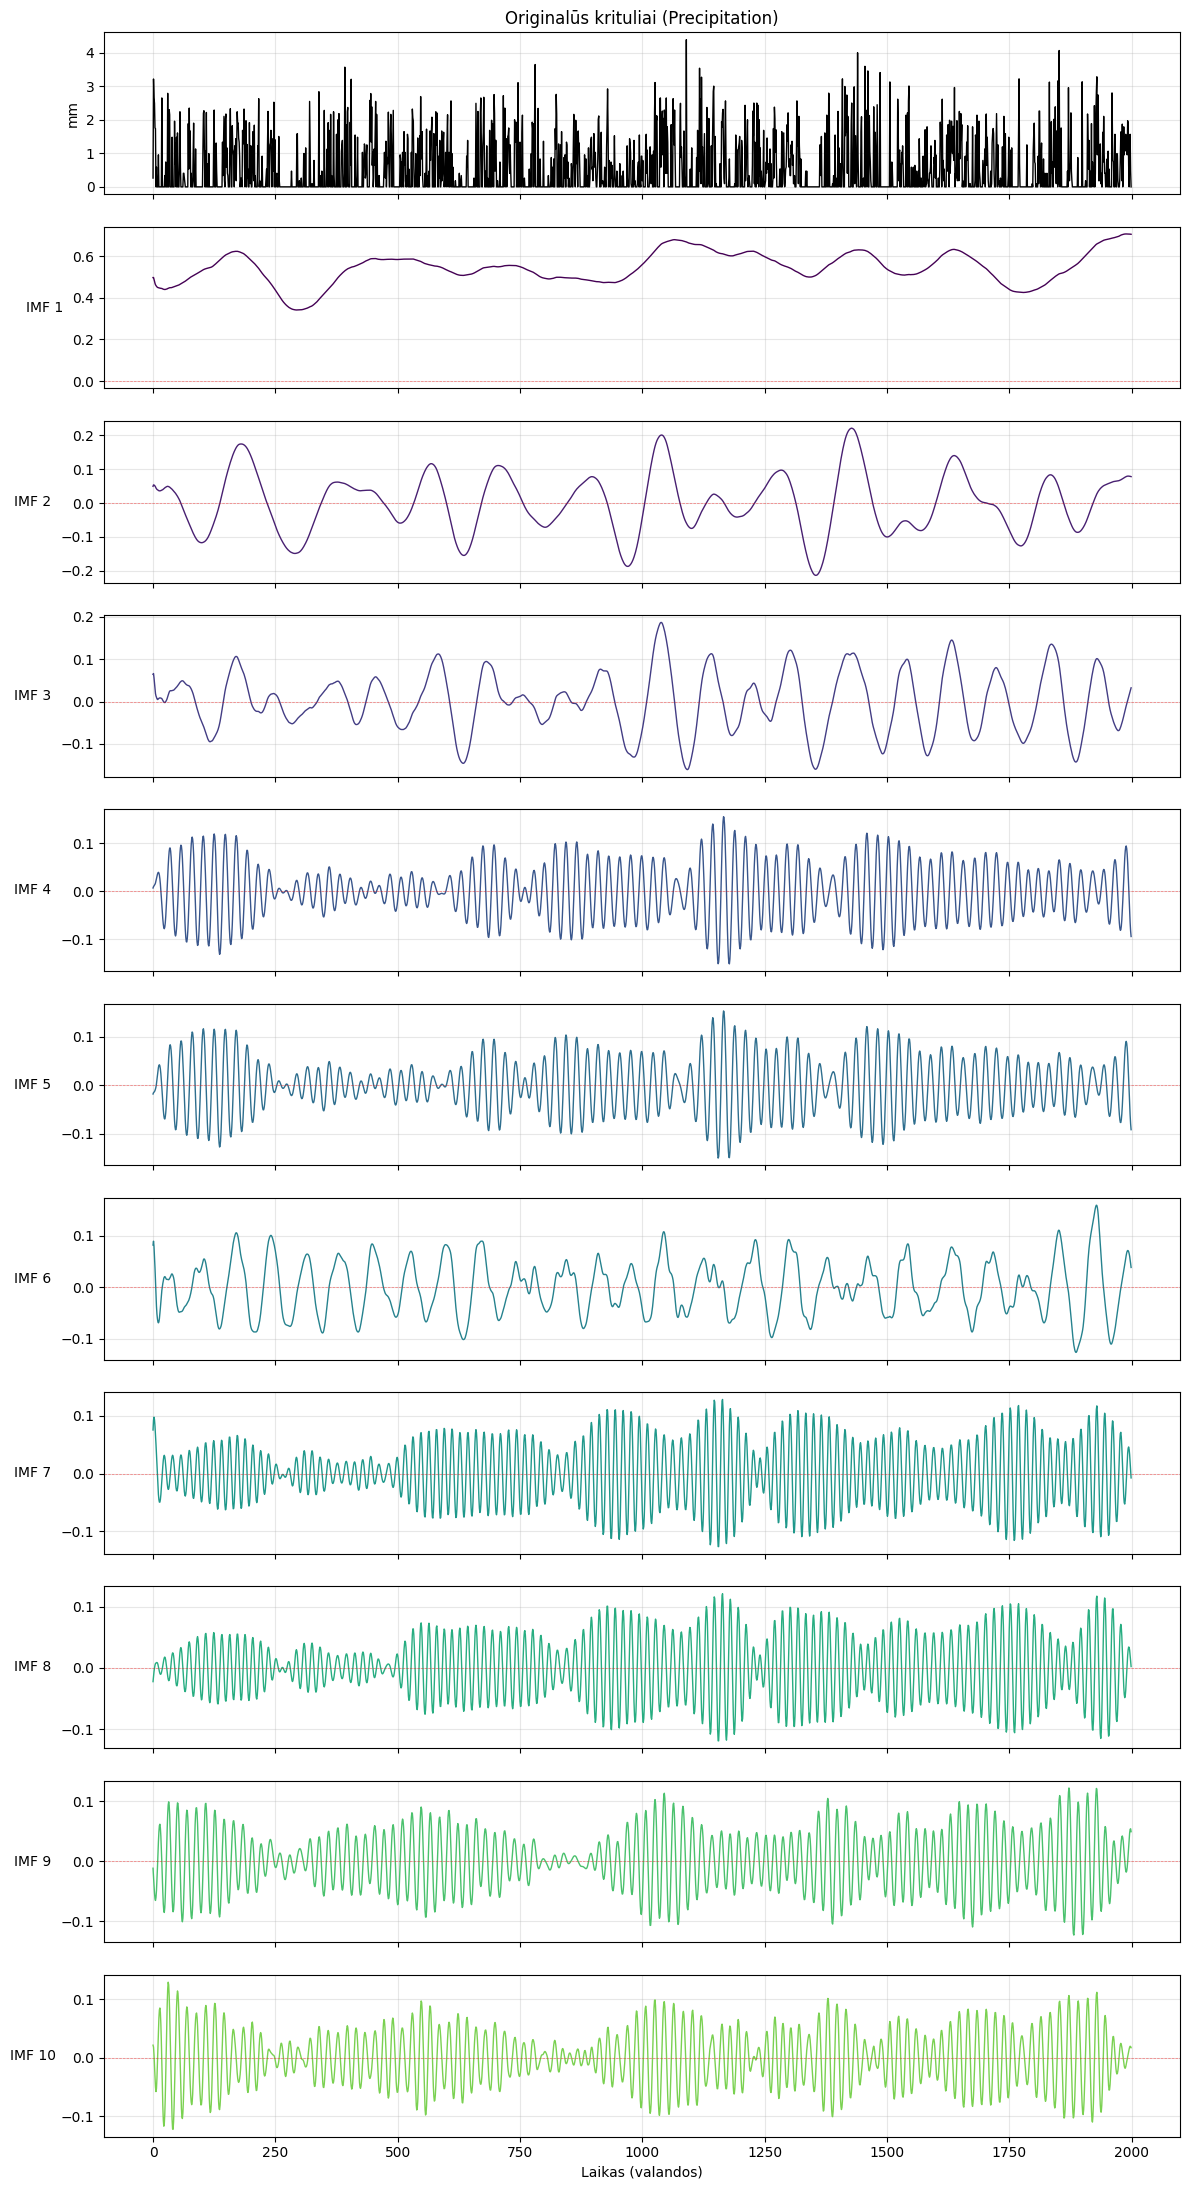

In [8]:
N = 10

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

# Nustatome segmentą vizualizacijai (pvz., pirmos 2000 valandų)
n_points = min(2000, len(series))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, series[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

# Komponenčių grafikai
colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, components[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    
    # Pridedame nulio liniją geresniam matomumui
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

# Ašies nustatymai
axes[-1].set_xlabel('Laikas (valandos)')

# Sutvarkome tarpus, kad grafikai nesuliptų
plt.tight_layout()
plt.subplots_adjust(hspace=0.2) # Galite pareguliuoti tarpus tarp grafikų

plt.show()

In [13]:
# how_group = {
#     '1': [0],
#     '2': [1, 2],
#     '3': [3, 4, 5, 6],
#     '4': np.arange(7, 90)
# }

how_group = {
    '1': [0],
    '2': [1],
    '3': [2],
    '4': [3, 4],
    '5': [5],
    '6': [6, 7, 8, 9],
    '7': [10, 11, 12],
    '8': np.arange(13, 39, 1)
}

grouped = []
for key in how_group:
    new_comp = np.zeros_like(components[0])
    for idx in how_group[key]:
        new_comp += components[idx]
    grouped.append(new_comp)

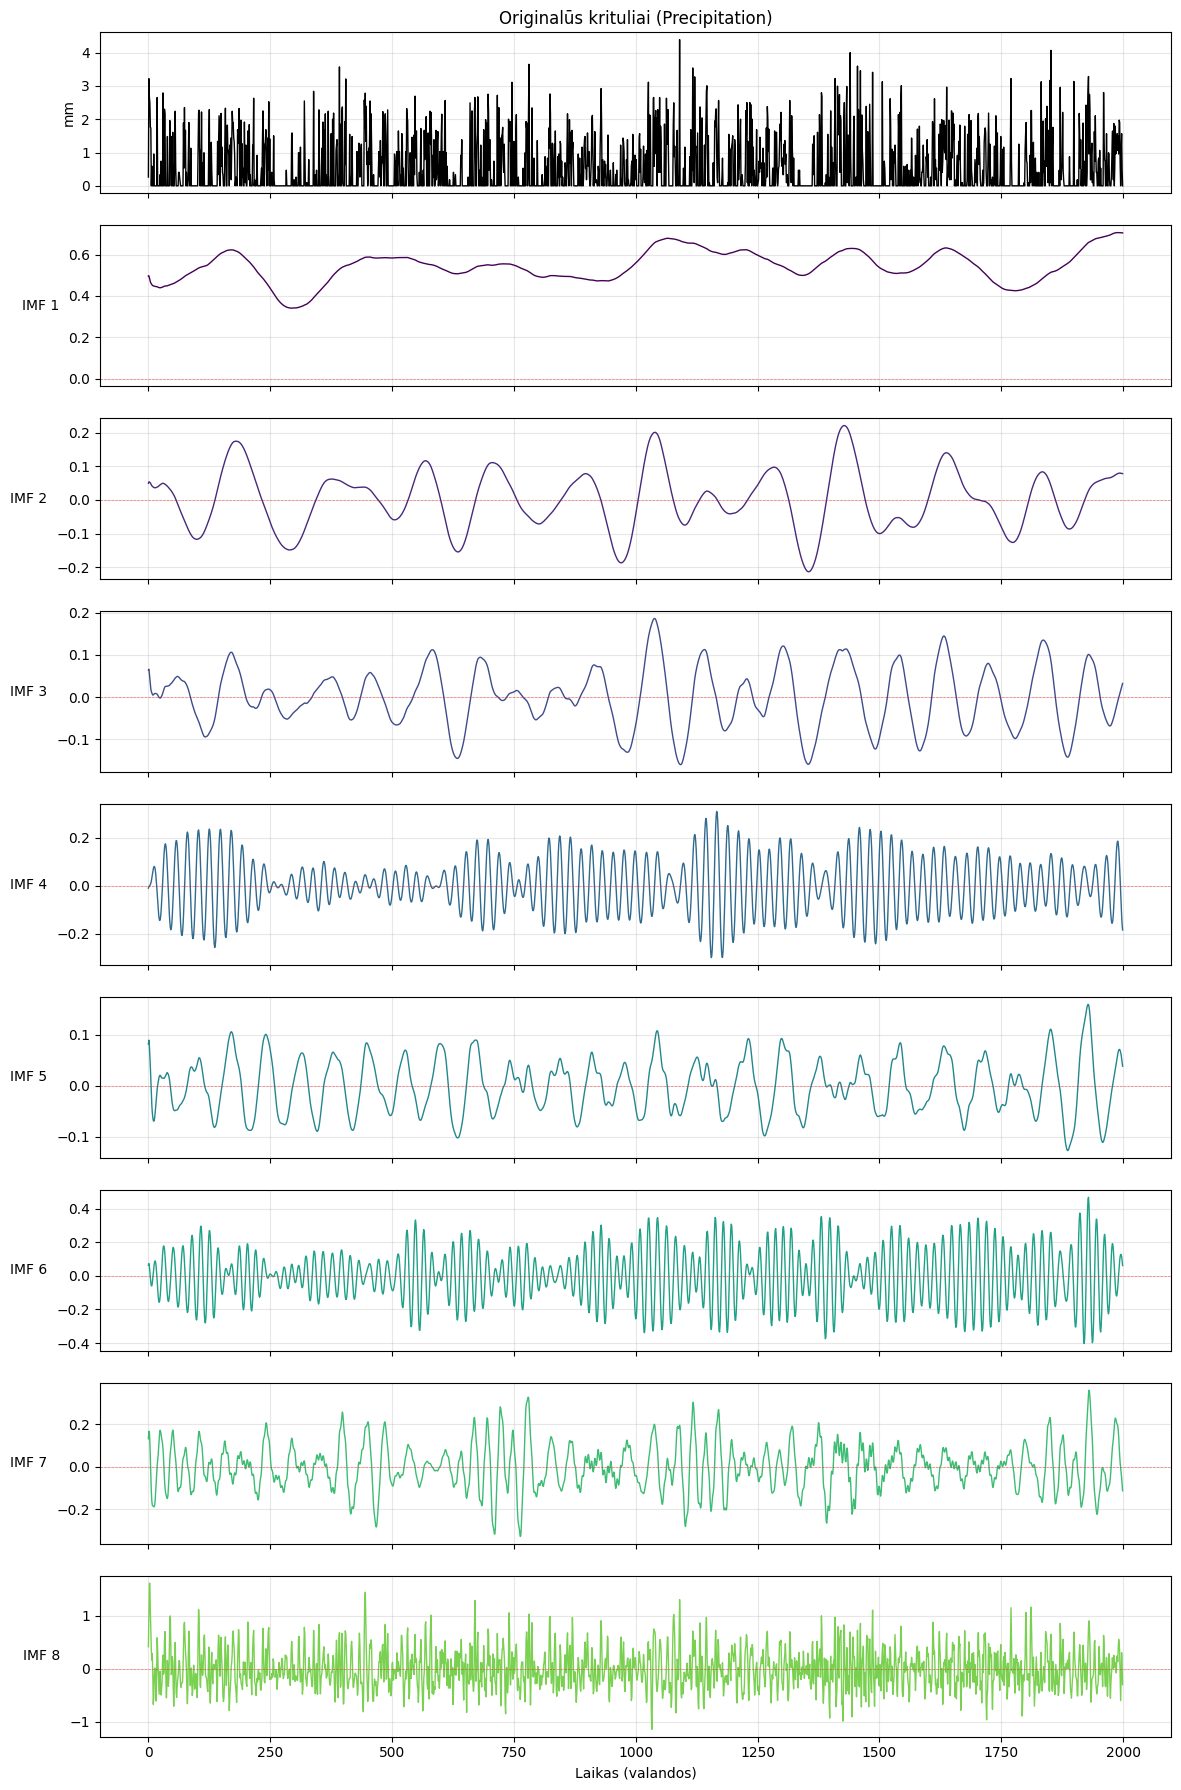

In [14]:
N = 8

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

# Nustatome segmentą vizualizacijai (pvz., pirmos 2000 valandų)
n_points = min(2000, len(series))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, series[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

# Komponenčių grafikai
colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, grouped[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    
    # Pridedame nulio liniją geresniam matomumui
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

# Ašies nustatymai
axes[-1].set_xlabel('Laikas (valandos)')

# Sutvarkome tarpus, kad grafikai nesuliptų
plt.tight_layout()
plt.subplots_adjust(hspace=0.2) # Galite pareguliuoti tarpus tarp grafikų

plt.show()

# SSA Mokymo testavimo aibės


## Skirstymas

In [15]:
split_idx = int(len(X) * 0.9)

X_train, X_test = X[:split_idx], X[split_idx:]

In [16]:
L = 120
n_comp = 120

ssa = SingularSpectrumAnalysis(window_size=L, lower_frequency_bound=0.1)

series = np.log1p(X_train['missforest_precipitation'].values)
y_ssa = series.reshape(1, -1)
all_components = ssa.fit_transform(y_ssa)
components_train = all_components[0]

ssa = SingularSpectrumAnalysis(window_size=L, lower_frequency_bound=0.1)

series = np.log1p(X_test['missforest_precipitation'].values)
y_ssa = series.reshape(1, -1)
all_components = ssa.fit_transform(y_ssa)
components_test = all_components[0]

In [17]:
# how_group = {
#     '1': [0],
#     '2': [1, 2],
#     '3': [3, 4, 5, 6],
#     '4': np.arange(7, 90)
# }

how_group = {
    '1': [0],
    '2': [1],
    '3': [2],
    '4': [3, 4],
    '5': [5],
    '6': [6, 7, 8, 9],
    '7': [10, 11, 12],
    '8': np.arange(13, 39, 1)
}

grouped_train = []
for key in how_group:
    new_comp = np.zeros_like(components_train[0])
    for idx in how_group[key]:
        new_comp += components_train[idx]
    grouped_train.append(new_comp)

grouped_test = []
for key in how_group:
    new_comp = np.zeros_like(components_test[0])
    for idx in how_group[key]:
        new_comp += components_test[idx]
    grouped_test.append(new_comp)

In [18]:
X_train['IMF1'] = grouped_train[0]
X_train['IMF2'] = grouped_train[1]
X_train['IMF3'] = grouped_train[2]
X_train['IMF4'] = grouped_train[3]
X_train['IMF5'] = grouped_train[4]
X_train['IMF6'] = grouped_train[5]
X_train['IMF7'] = grouped_train[6]
X_train['IMF8'] = grouped_train[7]

X_train['NO2_mean_7'] = X_train['NO2'].rolling(window=7).mean()
X_train['nmvoc_mean_5'] = X_train['nmvoc'].rolling(window=5).mean()
X_train['dust_mean_7'] = X_train['dust'].rolling(window=7).mean()
X_train['pm10_mean_5'] = X_train['pm10'].rolling(window=5).mean()

X_test['IMF1'] = grouped_test[0]
X_test['IMF2'] = grouped_test[1]
X_test['IMF3'] = grouped_test[2]
X_test['IMF4'] = grouped_test[3]
X_test['IMF5'] = grouped_test[4]
X_test['IMF6'] = grouped_test[5]
X_test['IMF7'] = grouped_test[6]
X_test['IMF8'] = grouped_test[7]

X_test['NO2_mean_7'] = X_test['NO2'].rolling(window=7).mean()
X_test['nmvoc_mean_5'] = X_test['nmvoc'].rolling(window=5).mean()
X_test['dust_mean_7'] = X_test['dust'].rolling(window=7).mean()
X_test['pm10_mean_5'] = X_test['pm10'].rolling(window=5).mean()

X_train = X_train.dropna()
X_test = X_test.dropna()

In [19]:
y_train = X_train[['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5', 'IMF6', 'IMF7', 'IMF8']]
y_test = X_test[['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5', 'IMF6', 'IMF7', 'IMF8']]

In [20]:
X_train = X_train[:-1].drop(columns=['observationTime'])
y_train = y_train[1:]

In [21]:
X_test = X_test[:-1].drop(columns=['observationTime'])
y_test = y_test[1:]

## IMF1

In [79]:
select_features_lasso(X_train, 'IMF1')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 10
Geriausias lambda (alpha): 0.0001
Pašalinti požymiai: ['tropopause_pressure', 'IMF2', 'IMF6', 'H2O_column_number_density', 'pm10_lag1', 'H2O_column_number_density_lag1', 'NO2_lag3', 'NO2', 'tp', 'month_cos', 'nh3', 'NO2_lag5', 'NO2_column_number_density', 'sia', 'dust_lag1', 'windDirection_fixed', 'IMF4', 'O3_Error', 'feelsLikeTemperature_fixed', 'nh3_lag1', 'month_sin', 'NO2_lag1', 'pm2p5', 'NO2_lag4', 'seaLevelPressure', 'nmvoc', 'windSpeed_fixed', 'pm10', 'dust_mean_7', 'pm10_mean_5', 'airTemperature', 'IMF7', 'NO2_Error', 'day_of_week', 'stratospheric_NO2_column_number_density', 'relativeHumidity', 'windGust_fixed', 'day_of_year', 'IMF8', 'nmvoc_lag1', 'nh3_lag2', 'NO2_lag6', 'missforest_precipitation', 'O3', 'NO2_lag2', 'NO2_column_number_density_lag1', 'BrO', 't2m', 'dust', 'nh3_lag11', 'IMF3', 'NO2_column_number_density_lag3', 'NO2_column_number_density_lag2', 'xgb_cloudCover', 'IMF5', 'BrO_Error', 'nmvoc_mean_5']


['absorbing_aerosol_index',
 'NO2_slant_column_number_density',
 'pans',
 'month',
 'pans_lag10',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'NO2_mean_7',
 'IMF1_lag0']

In [80]:
X_train_IMF1 = X_train[['absorbing_aerosol_index',
 'NO2_slant_column_number_density',
 'pans',
 'month',
 'pans_lag10',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'NO2_mean_7',
 'IMF1']]

X_test_IMF1 = X_test[['absorbing_aerosol_index',
 'NO2_slant_column_number_density',
 'pans',
 'month',
 'pans_lag10',
 'NO2_lag7',
 'NO2_lag8',
 'NO2_lag9',
 'NO2_mean_7',
 'IMF1']]

## IMF2

In [89]:
select_features_lasso(X_train, 'IMF2')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 18
Geriausias lambda (alpha): 0.0001
Pašalinti požymiai: ['dust_mean_7', 'pm10_mean_5', 'airTemperature', 'IMF7', 'NO2_Error', 'day_of_week', 'stratospheric_NO2_column_number_density', 'IMF1', 'IMF6', 'windGust_fixed', 'pm10_lag1', 'NO2_lag3', 'NO2', 'IMF8', 'nmvoc_lag1', 'nh3_lag2', 'pans_lag10', 'tp', 'NO2_lag6', 'NO2_lag5', 'O3', 'sia', 'NO2_lag9', 'NO2_mean_7', 'dust_lag1', 'NO2_column_number_density_lag1', 'windDirection_fixed', 'NO2_lag2', 'IMF4', 'NO2_lag8', 'feelsLikeTemperature_fixed', 'nh3_lag1', 'BrO', 'pans', 't2m', 'NO2_lag7', 'NO2_lag1', 'dust', 'nh3_lag11', 'pm2p5', 'NO2_lag4', 'NO2_column_number_density_lag3', 'NO2_column_number_density_lag2', 'seaLevelPressure', 'IMF5', 'nmvoc', 'BrO_Error', 'windSpeed_fixed', 'pm10']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'O3_Error',
 'nh3',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'month',
 'day_of_year',
 'month_sin',
 'month_cos',
 'H2O_column_number_density_lag1',
 'IMF3',
 'nmvoc_mean_5',
 'IMF2_lag0']

In [90]:
X_train_IMF2 = X_train[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'O3_Error',
 'nh3',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'month',
 'day_of_year',
 'month_sin',
 'month_cos',
 'H2O_column_number_density_lag1',
 'IMF3',
 'nmvoc_mean_5',
 'IMF2']]

X_test_IMF2 = X_test[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'O3_Error',
 'nh3',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'month',
 'day_of_year',
 'month_sin',
 'month_cos',
 'H2O_column_number_density_lag1',
 'IMF3',
 'nmvoc_mean_5',
 'IMF2']]

## IMF3

In [91]:
select_features_lasso(X_train, 'IMF3')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 14
Geriausias lambda (alpha): 0.0001
Pašalinti požymiai: ['IMF2', 'IMF6', 'H2O_column_number_density', 'pm10_lag1', 'NO2_lag3', 'NO2', 'tp', 'month_cos', 'nh3', 'NO2_lag5', 'NO2_column_number_density', 'sia', 'NO2_lag9', 'NO2_mean_7', 'dust_lag1', 'windDirection_fixed', 'IMF4', 'NO2_lag8', 'feelsLikeTemperature_fixed', 'nh3_lag1', 'NO2_lag1', 'pm2p5', 'NO2_lag4', 'nmvoc', 'windSpeed_fixed', 'pm10', 'pm10_mean_5', 'airTemperature', 'IMF7', 'NO2_Error', 'day_of_week', 'stratospheric_NO2_column_number_density', 'IMF1', 'day_of_year', 'IMF8', 'nmvoc_lag1', 'nh3_lag2', 'NO2_lag6', 'O3', 'NO2_lag2', 'NO2_column_number_density_lag1', 'NO2_slant_column_number_density', 'BrO', 'pans', 't2m', 'NO2_lag7', 'dust', 'nh3_lag11', 'NO2_column_number_density_lag3', 'NO2_column_number_density_lag2', 'xgb_cloudCover', 'IMF5', 'BrO_Error']


['absorbing_aerosol_index',
 'tropopause_pressure',
 'O3_Error',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'windGust_fixed',
 'month',
 'month_sin',
 'H2O_column_number_density_lag1',
 'pans_lag10',
 'nmvoc_mean_5',
 'dust_mean_7',
 'IMF3_lag0']

In [93]:
X_train_IMF3 = X_train[['absorbing_aerosol_index',
 'tropopause_pressure',
 'O3_Error',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'windGust_fixed',
 'month',
 'month_sin',
 'H2O_column_number_density_lag1',
 'pans_lag10',
 'nmvoc_mean_5',
 'dust_mean_7',
 'IMF3']]

X_test_IMF3 = X_test[['absorbing_aerosol_index',
 'tropopause_pressure',
 'O3_Error',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'windGust_fixed',
 'month',
 'month_sin',
 'H2O_column_number_density_lag1',
 'pans_lag10',
 'nmvoc_mean_5',
 'dust_mean_7',
 'IMF3']]

## IMF4

In [94]:
select_features_lasso(X_train, 'IMF4')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 8
Geriausias lambda (alpha): 0.0008
Pašalinti požymiai: ['tropopause_pressure', 'IMF2', 'IMF6', 'month', 'H2O_column_number_density', 'pm10_lag1', 'H2O_column_number_density_lag1', 'NO2_lag3', 'NO2', 'month_cos', 'nh3', 'NO2_lag5', 'absorbing_aerosol_index', 'NO2_column_number_density', 'sia', 'NO2_lag9', 'NO2_mean_7', 'windDirection_fixed', 'NO2_lag8', 'O3_Error', 'feelsLikeTemperature_fixed', 'nh3_lag1', 'month_sin', 'NO2_lag1', 'pm2p5', 'NO2_lag4', 'seaLevelPressure', 'nmvoc', 'pm10', 'airTemperature', 'IMF7', 'NO2_Error', 'day_of_week', 'stratospheric_NO2_column_number_density', 'IMF1', 'windGust_fixed', 'day_of_year', 'IMF8', 'nmvoc_lag1', 'nh3_lag2', 'pans_lag10', 'NO2_lag6', 'missforest_precipitation', 'O3', 'NO2_lag2', 'NO2_column_number_density_lag1', 'NO2_slant_column_number_density', 'BrO', 'pans', 't2m', 'NO2_lag7', 'nh3_lag11', 'IMF3', 'NO2_column_number_density_lag3', 'NO2_column_number_density_lag2', 'xgb_cloudCov

['dust',
 'tp',
 'relativeHumidity',
 'windSpeed_fixed',
 'dust_lag1',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF4_lag0']

In [96]:
X_train_IMF4 = X_train[['dust',
 'tp',
 'relativeHumidity',
 'windSpeed_fixed',
 'dust_lag1',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF4']]

X_test_IMF4 = X_test[['dust',
 'tp',
 'relativeHumidity',
 'windSpeed_fixed',
 'dust_lag1',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF4']]

## IMF5

In [97]:
select_features_lasso(X_train, 'IMF5')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 12
Geriausias lambda (alpha): 0.0002
Pašalinti požymiai: ['tropopause_pressure', 'IMF2', 'H2O_column_number_density', 'pm10_lag1', 'H2O_column_number_density_lag1', 'NO2_lag3', 'NO2', 'month_cos', 'nh3', 'NO2_lag5', 'absorbing_aerosol_index', 'NO2_column_number_density', 'sia', 'NO2_lag9', 'NO2_mean_7', 'dust_lag1', 'windDirection_fixed', 'IMF4', 'NO2_lag8', 'O3_Error', 'feelsLikeTemperature_fixed', 'nh3_lag1', 'month_sin', 'NO2_lag1', 'pm2p5', 'NO2_lag4', 'nmvoc', 'pm10', 'dust_mean_7', 'airTemperature', 'IMF7', 'NO2_Error', 'day_of_week', 'stratospheric_NO2_column_number_density', 'IMF1', 'IMF8', 'nmvoc_lag1', 'nh3_lag2', 'pans_lag10', 'NO2_lag6', 'missforest_precipitation', 'NO2_lag2', 'NO2_column_number_density_lag1', 'NO2_slant_column_number_density', 'BrO', 'pans', 't2m', 'NO2_lag7', 'dust', 'nh3_lag11', 'IMF3', 'NO2_column_number_density_lag3', 'NO2_column_number_density_lag2', 'xgb_cloudCover', 'BrO_Error']


['O3',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'windSpeed_fixed',
 'windGust_fixed',
 'month',
 'day_of_year',
 'IMF6',
 'nmvoc_mean_5',
 'pm10_mean_5',
 'IMF5_lag0']

In [98]:
X_train_IMF5 = X_train[['O3',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'windSpeed_fixed',
 'windGust_fixed',
 'month',
 'day_of_year',
 'IMF6',
 'nmvoc_mean_5',
 'pm10_mean_5',
 'IMF5']]

X_test_IMF5 = X_test[['O3',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'windSpeed_fixed',
 'windGust_fixed',
 'month',
 'day_of_year',
 'IMF6',
 'nmvoc_mean_5',
 'pm10_mean_5',
 'IMF5']]

## IMF6

In [99]:
select_features_lasso(X_train, 'IMF6')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 7
Geriausias lambda (alpha): 0.0019
Pašalinti požymiai: ['tropopause_pressure', 'IMF2', 'month', 'pm10_lag1', 'H2O_column_number_density_lag1', 'NO2_lag3', 'NO2', 'month_cos', 'nh3', 'NO2_lag5', 'absorbing_aerosol_index', 'NO2_column_number_density', 'sia', 'NO2_lag9', 'NO2_mean_7', 'dust_lag1', 'windDirection_fixed', 'IMF4', 'NO2_lag8', 'O3_Error', 'feelsLikeTemperature_fixed', 'nh3_lag1', 'month_sin', 'NO2_lag1', 'pm2p5', 'NO2_lag4', 'seaLevelPressure', 'nmvoc', 'windSpeed_fixed', 'pm10', 'dust_mean_7', 'airTemperature', 'IMF7', 'NO2_Error', 'day_of_week', 'stratospheric_NO2_column_number_density', 'IMF1', 'relativeHumidity', 'windGust_fixed', 'day_of_year', 'IMF8', 'nmvoc_lag1', 'nh3_lag2', 'NO2_lag6', 'missforest_precipitation', 'NO2_lag2', 'NO2_column_number_density_lag1', 'BrO', 'pans', 't2m', 'NO2_lag7', 'dust', 'nh3_lag11', 'IMF3', 'NO2_column_number_density_lag3', 'NO2_column_number_density_lag2', 'xgb_cloudCover', 'IMF

['NO2_slant_column_number_density',
 'H2O_column_number_density',
 'O3',
 'tp',
 'pans_lag10',
 'pm10_mean_5',
 'IMF6_lag0']

In [101]:
X_train_IMF6 = X_train[['NO2_slant_column_number_density',
 'H2O_column_number_density',
 'O3',
 'tp',
 'pans_lag10',
 'pm10_mean_5',
 'IMF6']]

X_test_IMF6 = X_test[['NO2_slant_column_number_density',
 'H2O_column_number_density',
 'O3',
 'tp',
 'pans_lag10',
 'pm10_mean_5',
 'IMF6']]

## IMF7

In [102]:
select_features_lasso(X_train, 'IMF7')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 30
Geriausias lambda (alpha): 0.0003
Pašalinti požymiai: ['airTemperature', 'NO2_Error', 'IMF2', 'day_of_week', 'stratospheric_NO2_column_number_density', 'IMF1', 'month', 'windGust_fixed', 'pm10_lag1', 'H2O_column_number_density_lag1', 'NO2_lag3', 'month_cos', 'NO2_lag6', 'nh3', 'NO2_lag5', 'missforest_precipitation', 'sia', 'NO2_mean_7', 'dust_lag1', 'NO2_column_number_density_lag1', 'NO2_lag2', 'IMF4', 'NO2_lag8', 'O3_Error', 'nh3_lag1', 'BrO', 't2m', 'NO2_lag7', 'month_sin', 'NO2_lag1', 'dust', 'pm2p5', 'NO2_lag4', 'IMF3', 'BrO_Error', 'windSpeed_fixed', 'pm10']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'NO2',
 'O3',
 'nmvoc',
 'pans',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windDirection_fixed',
 'day_of_year',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pans_lag10',
 'NO2_lag9',
 'IMF5',
 'IMF6',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF7_lag0']

In [103]:
X_train_IMF7 = X_train[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'NO2',
 'O3',
 'nmvoc',
 'pans',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windDirection_fixed',
 'day_of_year',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pans_lag10',
 'NO2_lag9',
 'IMF5',
 'IMF6',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF7']]

X_test_IMF7 = X_test[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'NO2',
 'O3',
 'nmvoc',
 'pans',
 'tp',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windDirection_fixed',
 'day_of_year',
 'NO2_column_number_density_lag2',
 'NO2_column_number_density_lag3',
 'nmvoc_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pans_lag10',
 'NO2_lag9',
 'IMF5',
 'IMF6',
 'IMF8',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF7']]

## IMF8

In [104]:
select_features_lasso(X_train, 'IMF8')

Pradinis požymių skaičius: 67
Išlikusių požymių skaičius: 44
Geriausias lambda (alpha): 0.0014
Pašalinti požymiai: ['airTemperature', 'NO2_Error', 'NO2_lag3', 'day_of_year', 'H2O_column_number_density_lag1', 'nmvoc_lag1', 'month_cos', 'NO2_lag5', 'missforest_precipitation', 'O3', 'NO2_lag9', 'NO2_mean_7', 'NO2_lag2', 'NO2_column_number_density_lag1', 'O3_Error', 'pans', 'month_sin', 'dust', 'pm2p5', 'NO2_column_number_density_lag3', 'NO2_column_number_density_lag2', 'BrO_Error', 'pm10']


['absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'sia',
 'nmvoc',
 'nh3',
 'tp',
 't2m',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'day_of_week',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag4',
 'NO2_lag6',
 'NO2_lag7',
 'NO2_lag8',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF4',
 'IMF5',
 'IMF6',
 'IMF7',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF8_lag0']

In [105]:
X_train_IMF8 = X_train[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'sia',
 'nmvoc',
 'nh3',
 'tp',
 't2m',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'day_of_week',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag4',
 'NO2_lag6',
 'NO2_lag7',
 'NO2_lag8',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF4',
 'IMF5',
 'IMF6',
 'IMF7',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF8']]

X_test_IMF8 = X_test[['absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'NO2',
 'sia',
 'nmvoc',
 'nh3',
 'tp',
 't2m',
 'seaLevelPressure',
 'relativeHumidity',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed',
 'month',
 'day_of_week',
 'nh3_lag1',
 'nh3_lag2',
 'nh3_lag11',
 'pm10_lag1',
 'pans_lag10',
 'dust_lag1',
 'NO2_lag1',
 'NO2_lag4',
 'NO2_lag6',
 'NO2_lag7',
 'NO2_lag8',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF4',
 'IMF5',
 'IMF6',
 'IMF7',
 'nmvoc_mean_5',
 'dust_mean_7',
 'pm10_mean_5',
 'IMF8']]

# LSTM

In [24]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, time, features)
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)

In [25]:
class SequenceScaler:
    """Standartizuoja X ir suformuoja sliding window sekas."""
    def __init__(self, window_size):
        self.window_size = window_size
        self.scaler = StandardScaler()

    def fit(self, X):
        self.scaler.fit(X)
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        X_seq = []
        for i in range(len(X_scaled) - self.window_size):
            X_seq.append(X_scaled[i:i + self.window_size])
        return np.array(X_seq)

In [26]:
class TweedieLoss(nn.Module):
    """
    Tweedie loss su log-link.
    Reikalauja: target >= 0  (krituliai visada >= 0 ✓)

    LSTM output pred — neribojamas (log erdvė)
    μ = exp(pred) > 0  (nereikia aktyvacijos)

    Gradientas dL/d(pred) = -y·μ^(1-p) + μ^(2-p)
    Kai y=15: gradientas ~20x didesnis nei kai y=0.5
    → modelis stipriai baudžiamas už šuolių praleidimą
    """
    def __init__(self, p=1.5):
        super().__init__()
        assert 1 < p < 2
        self.p = p

    def forward(self, pred, target):
        pred   = pred.squeeze(-1)
        target = target.squeeze(-1)
        mu = torch.exp(pred)
        p  = self.p
        return (-target * mu.pow(1 - p) / (1 - p) + mu.pow(2 - p) / (2 - p)).mean()

In [27]:
class LSTMNet(NeuralNetRegressor):
    def __init__(self, base_module, window_size=10, **net_params):
        self.base_module = base_module
        self.window_size = window_size
        if 'module' not in net_params:
            net_params['module'] = base_module

        super().__init__(**net_params)

    # def __sklearn_tags__(self):
    #     return {"estimator_type": "regressor"}

    # def fit(self, X, y, **fit_params):
    #     ws = self.window_size

    #     # 1. Features: sliding window sekos
    #     self.seq = SequenceScaler(window_size=ws)
    #     self.seq.fit(X)
    #     X_seq = self.seq.transform(X)        # (N-ws, ws, F)

    #     # 2. Target standartizacija
    #     # self.y_scaler = StandardScaler()
    #     # y_scaled = self.y_scaler.fit_transform(y.reshape(-1, 1)).ravel()  # (N,)
    #     y_scaled = y.reshape(-1, 1)

    #     # 3. Alignment: X_seq[j] -> window [j, j+ws), target = y[j+ws]
    #     y_trunc = y_scaled[ws:]              # (N-ws,)

    #     # 4. Vienas LSTM visam targetui
    #     self.model = NeuralNetRegressor(
    #         module=self.base_module,
    #         module__input_dim=X_seq.shape[2],
    #         train_split=ValidSplit(0.2),
    #         callbacks=[
    #             Checkpoint(monitor='valid_loss_best', load_best=True),
    #             EarlyStopping(patience=20)
    #         ],
    #         **self.net_params
    #     )
    #     self.model.fit(X_seq.astype(np.float32), y_trunc.astype(np.float32))
    #     return self
    
    def fit(self, X, y, **fit_params):
        ws = self.window_size

        # 1. Paruošiame sekas (naudojame self.window_size, kurį GridSearch keis)
        self.seq = SequenceScaler(window_size=ws)
        self.seq.fit(X)
        X_seq = self.seq.transform(X)        # (N-ws, ws, F)

        # 2. Target paruošimas (suvienodiname ilgį su X_seq)
        y_trunc = y[ws:].reshape(-1, 1)      # (N-ws, 1)

        # 3. Konvertuojame į float32 (būtina PyTorch)
        X_seq = X_seq.astype(np.float32)
        y_trunc = y_trunc.astype(np.float32)

        # 4. SVARBU: Atnaujiname modelio parametrus prieš treniravimą
        # Kadangi paveldime iš NeuralNetRegressor, parametrai nustatomi per self.set_params
        self.set_params(module__input_dim=X_seq.shape[2])
        
        # Pridedame EarlyStopping ir kitus callbacks, jei jų dar nėra
        if 'callbacks' not in self.get_params():
             self.set_params(callbacks=[
                Checkpoint(monitor='valid_loss_best', load_best=True),
                EarlyStopping(patience=20)
            ])

        # 5. Kviečiame bazinį skorch fit su apdorotais duomenimis
        # Tai leis GridSearchCV matyti progresą ir skaičiuoti score
        return super().fit(X_seq, y_trunc, **fit_params)
    
    def predict(self, X):
        # 1. Paruošiame sekas iš X_test naudojant fit metu sukurtą seq objektą
        X_seq = self.seq.transform(X)        # (M-ws, ws, F)
        
        # 2. Kviečiame bazinį skorch predict metodą
        # Nebenaudojame self.model.predict, o naudojame super().predict
        y_scaled_pred = super().predict(X_seq.astype(np.float32))
        
        # 3. Grąžiname rezultatą (be de-standartizacijos, jei jos nenaudoji)
        return y_scaled_pred.reshape(-1, 1)

# SSA-LSTM
## IMF1

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

In [111]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=14,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.2,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=750,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [112]:
pipeline.fit(X_train_IMF1.values, y_train['IMF1'].values)
pred = pipeline.predict(X_test_IMF1.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0225        0.0045     +  0.3296
      2        0.0050        0.0009     +  0.1816
      3        0.0004        0.0001     +  0.1660
      4        0.0001        0.0001     +  0.1658
      5        0.0001        0.0001     +  0.1658
      6        0.0001        0.0001        0.1676
      7        0.0001        0.0001        0.1656
      8        0.0001        0.0001        0.1632
      9        0.0001        0.0001        0.1667
     10        0.0001        0.0001        0.1688
     11        0.0001        0.0001     +  0.1684
     12        0.0001        0.0001        0.1597
     13        0.0001        0.0000     +  0.1551
     14        0.0001        0.0001        0.1684
     15        0.0001        0.0000        0.1862
     16        0.0001        0.0001        0.1578
     17        0.0001        0.0000     +  0.1588
     18        0.0000        0.0000        0.1536


In [110]:
param_grid = {
    'window_size': [14],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF1.values, y_train['IMF1'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF1.values)

Fitting 2 folds for each of 18 candidates, totalling 36 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0606        0.0200     +  0.2047
      2        0.0047        0.0035     +  0.1821
      3        0.0034        0.0015     +  0.1089
      4        0.0007        0.0004     +  0.1201
      5        0.0003        0.0002     +  0.1003
      6        0.0002        0.0002        0.1086
      7        0.0001        0.0001     +  0.1082
      8        0.0001        0.0002        0.1184
      9        0.0001        0.0002        0.1206
     10        0.0001        0.0001        0.1072
     11        0.0001        0.0002        0.1241
     12        0.0001        0.0002        0.1079
     13        0.0001        0.0002        0.0812
     14        0.0001        0.0001     +  0.0855
     15        0.0001        0.0001     +  0.0819
     16        0.0001        0.0001        0.0815
     17        0.0001        0.0001    

In [113]:
y_true = y_test['IMF1'].values.astype(float)
y_true = np.expm1(y_true)

y_true =  y_true[14:]
y_pred = np.array(pred).reshape(-1)
y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF1 = y_true
y_pred_IMF1 = y_pred

RMSE:     0.0273
MAE:      0.0209
R2:       0.9915
Spearman: 0.9967


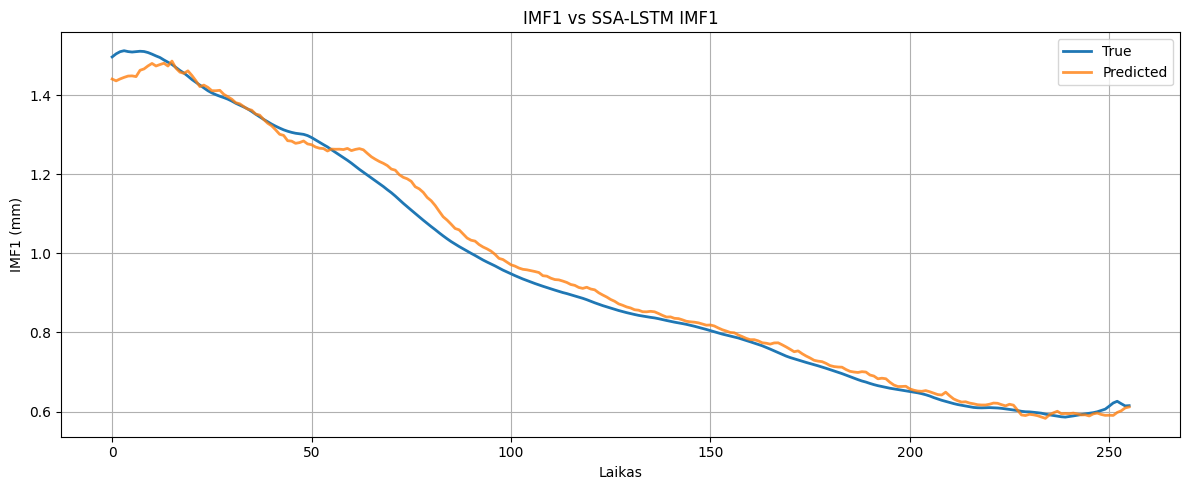

In [114]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF1 vs SSA-LSTM IMF1")
plt.xlabel("Laikas")
plt.ylabel("IMF1 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF2

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

In [120]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=14,

    module__hidden_dim=128,
    module__num_layers=1,
    module__dropout=0.1,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=20, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [121]:
pipeline.fit(X_train_IMF2.values, y_train['IMF2'].values)
pred = pipeline.predict(X_test_IMF2.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0018        0.0003     +  0.4400
      2        0.0003        0.0003     +  0.2377
      3        0.0002        0.0002     +  0.2483
      4        0.0002        0.0001     +  0.2317
      5        0.0003        0.0002        0.2480
      6        0.0004        0.0003        0.2425
      7        0.0003        0.0002        0.2373
      8        0.0001        0.0001     +  0.2425
      9        0.0001        0.0001        0.2447
     10        0.0001        0.0001        0.2386
     11        0.0001        0.0001        0.2355
     12        0.0000        0.0001     +  0.2438
     13        0.0000        0.0001        0.2502
     14        0.0001        0.0001        0.2426
     15        0.0001        0.0001        0.2297
     16        0.0001        0.0001        0.2521
     17        0.0001        0.0001        0.2863
     18        0.0001        0.0001        0.2625


In [119]:
param_grid = {
    'window_size': [14],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF2.values, y_train['IMF2'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF2.values)

Fitting 2 folds for each of 36 candidates, totalling 72 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0071        0.0016     +  0.2246
      2        0.0015        0.0010     +  0.1596
      3        0.0003        0.0007     +  0.1103
      4        0.0002        0.0006     +  0.1355
      5        0.0001        0.0005     +  0.1288
      6        0.0001        0.0005     +  0.1120
      7        0.0001        0.0005     +  0.1137
      8        0.0001        0.0004     +  0.1291
      9        0.0001        0.0004     +  0.1188
     10        0.0001        0.0004     +  0.1367
     11        0.0001        0.0004     +  0.1298
     12        0.0001        0.0003     +  0.1051
     13        0.0001        0.0003     +  0.1045
     14        0.0001        0.0004        0.1199
     15        0.0002        0.0004        0.1164
     16        0.0003        0.0003        0.1344
     17        0.0013        0.0006    

In [122]:
y_true = y_test['IMF2'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[14:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF2 = y_true
y_pred_IMF2 = y_pred

RMSE:     0.0135
MAE:      0.0111
R2:       0.9854
Spearman: 0.9926


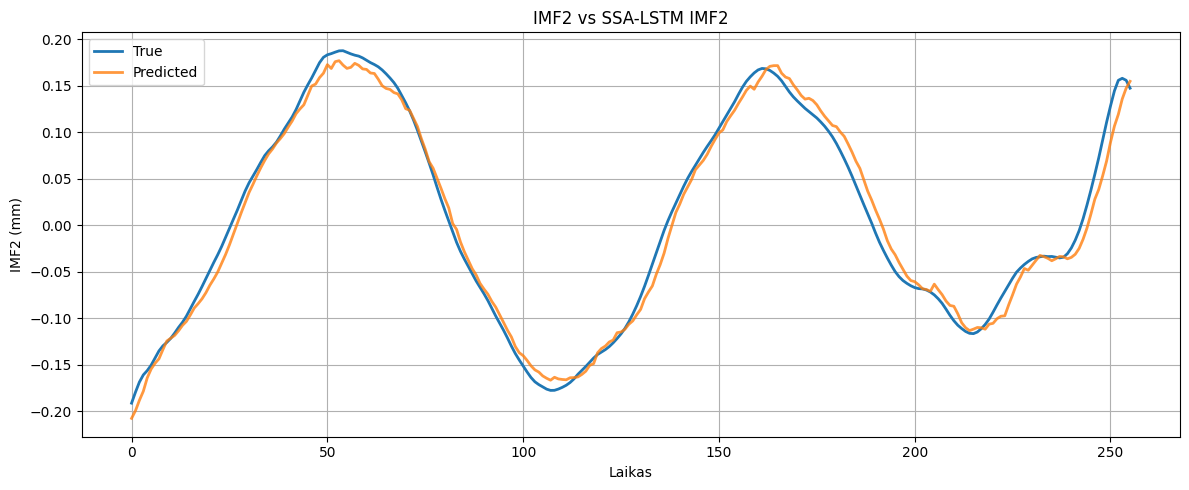

In [123]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF2 vs SSA-LSTM IMF2")
plt.xlabel("Laikas")
plt.ylabel("IMF2 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF3

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

In [125]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=14,

    module__hidden_dim=128,
    module__num_layers=1,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=20, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    # criterion=nn.HuberLoss(delta=1.0),
    criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [126]:
pipeline.fit(X_train_IMF3.values, y_train['IMF3'].values)
pred = pipeline.predict(X_test_IMF3.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0033        0.0008     +  0.4334
      2        0.0007        0.0002     +  0.2463
      3        0.0003        0.0003        0.2531
      4        0.0003        0.0002        0.2162
      5        0.0003        0.0002     +  0.2232
      6        0.0002        0.0002     +  0.2293
      7        0.0002        0.0001     +  0.3035
      8        0.0002        0.0001     +  0.2550
      9        0.0001        0.0001     +  0.2423
     10        0.0001        0.0001     +  0.2346
     11        0.0001        0.0001        0.2721
     12        0.0002        0.0004        0.2734
     13        0.0005        0.0004        0.2703
     14        0.0002        0.0002        0.2627
     15        0.0002        0.0001     +  0.2955
     16        0.0001        0.0001     +  0.2667
     17        0.0000        0.0001     +  0.2597
     18        0.0000        0.0001        0.2397


In [124]:
param_grid = {
    'window_size': [14],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF3.values, y_train['IMF3'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF3.values)

Fitting 2 folds for each of 36 candidates, totalling 72 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0043        0.0009     +  0.2331
      2        0.0007        0.0004     +  0.1838
      3        0.0003        0.0003     +  0.1175
      4        0.0002        0.0002     +  0.1126
      5        0.0001        0.0002     +  0.1050
      6        0.0001        0.0002     +  0.1072
      7        0.0001        0.0002     +  0.1214
      8        0.0001        0.0002     +  0.1037
      9        0.0001        0.0002        0.0911
     10        0.0000        0.0002     +  0.0844
     11        0.0000        0.0002        0.0795
     12        0.0000        0.0002     +  0.0794
     13        0.0000        0.0002     +  0.0852
     14        0.0000        0.0002     +  0.0766
     15        0.0000        0.0002     +  0.0780
     16        0.0000        0.0002     +  0.0777
     17        0.0000        0.0002    

In [127]:
y_true = y_test['IMF3'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[14:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF3 = y_true
y_pred_IMF3 = y_pred

RMSE:     0.0077
MAE:      0.0061
R2:       0.9936
Spearman: 0.9984


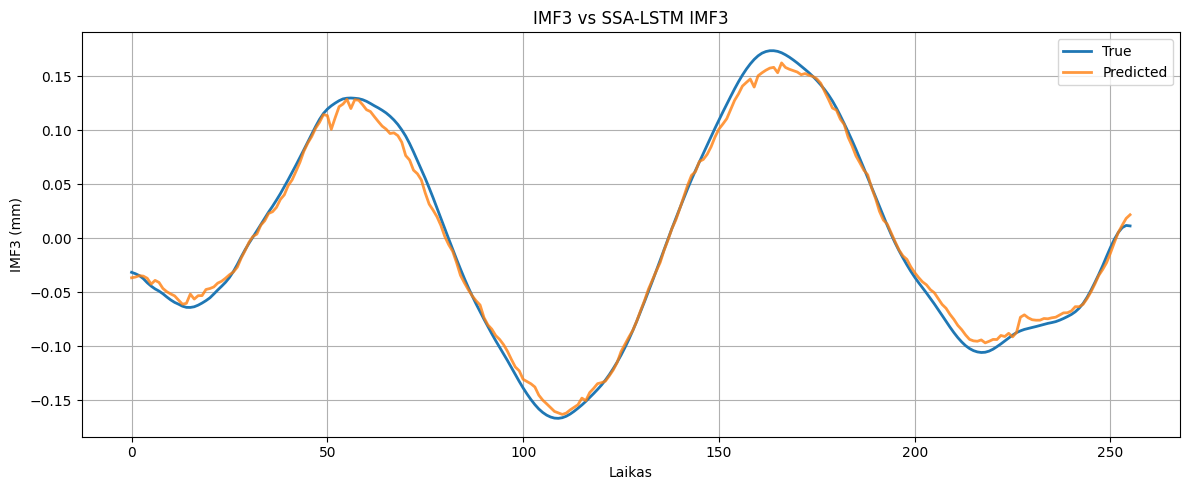

In [128]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF3 vs SSA-LSTM IMF3")
plt.xlabel("Laikas")
plt.ylabel("IMF3 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF4

In [130]:
class LSTMFCRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Vietoj vieno fc sluoksnio, naudojame Sequential bloką su LeakyReLU.
        # Tai padeda modeliui "ištraukti" triukšmo pikus, kurių paprastas fc nepagautų.
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1), 
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        # Naudojame paskutinį laiko žingsnį
        return self.fc(out[:, -1, :])

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

In [323]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.1,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=10, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=nn.HuberLoss(delta=0.6),
    criterion=nn.L1Loss(),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [324]:
pipeline.fit(X_train_IMF4.values, y_train['IMF4'].values)
pred = pipeline.predict(X_test_IMF4.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0807        0.0557     +  0.5261
      2        0.0430        0.0328     +  0.3179
      3        0.0195        0.0168     +  0.3111
      4        0.0276        0.0223        0.2530
      5        0.0198        0.0133     +  0.2514
      6        0.0147        0.0112     +  0.2691
      7        0.0133        0.0087     +  0.2509
      8        0.0117        0.0131        0.2445
      9        0.0120        0.0087        0.2535
     10        0.0135        0.0157        0.2428
     11        0.0136        0.0086     +  0.2421
     12        0.0112        0.0097        0.2342
     13        0.0097        0.0064     +  0.2387
     14        0.0101        0.0087        0.2508
     15        0.0100        0.0067        0.2635
     16        0.0088        0.0060     +  0.3115
     17        0.0088        0.0061        0.3359
     18        0.0099        0.0113        0.3813


In [132]:
param_grid = {
    'window_size': [14],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF4.values, y_train['IMF4'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF4.values)

Fitting 2 folds for each of 36 candidates, totalling 72 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0028        0.0089     +  0.2395
      2        0.0014        0.0069     +  0.1427
      3        0.0010        0.0045     +  0.1183
      4        0.0006        0.0021     +  0.1212
      5        0.0003        0.0008     +  0.1300
      6        0.0002        0.0005     +  0.1248
      7        0.0001        0.0004     +  0.1408
      8        0.0001        0.0007        0.1167
      9        0.0001        0.0005        0.1324
     10        0.0001        0.0004     +  0.1110
     11        0.0001        0.0005        0.1059
     12        0.0001        0.0005        0.1057
     13        0.0001        0.0005        0.1094
     14        0.0002        0.0010        0.0993
     15        0.0002        0.0004        0.1139
     16        0.0001        0.0003     +  0.1072
     17        0.0000        0.0004    

In [325]:
y_true = y_test['IMF4'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[4:]
y_pred = np.array(pred).reshape(-1)[:-1] *-0.55
# y_pred = np.expm1(y_pred)


rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF4 = y_true[11:]
y_pred_IMF4 = y_pred[11:]

RMSE:     0.0868
MAE:      0.0645
R2:       0.7120
Spearman: 0.8757


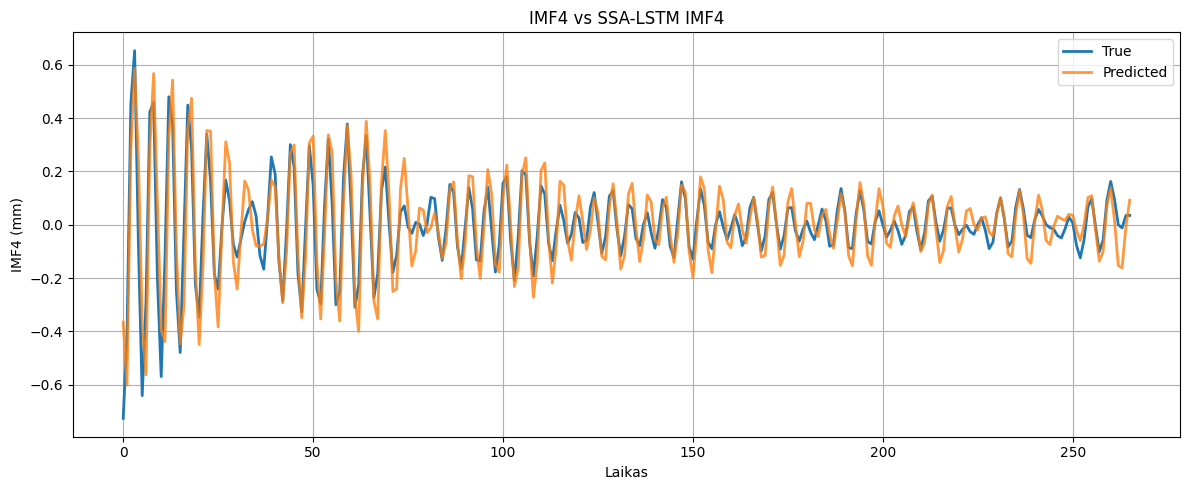

In [261]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF4 vs SSA-LSTM IMF4")
plt.xlabel("Laikas")
plt.ylabel("IMF4 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF5

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

In [263]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=14,

    module__hidden_dim=128,
    module__num_layers=1,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.6),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [ ]:
pipeline.fit(X_train_IMF5.values, y_train['IMF5'].values)
pred = pipeline.predict(X_test_IMF5.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0014        0.0001     +  0.3884
      2        0.0001        0.0001     +  0.2496
      3        0.0001        0.0001     +  0.2524
      4        0.0001        0.0001     +  0.2442
      5        0.0000        0.0000     +  0.2305
      6        0.0000        0.0001        0.2336
      7        0.0003        0.0007        0.2258
      8        0.0003        0.0001        0.2272
      9        0.0000        0.0000     +  0.2182
     10        0.0000        0.0000     +  0.2287
     11        0.0000        0.0000     +  0.2212
     12        0.0000        0.0000     +  0.2342
     13        0.0000        0.0000     +  0.2482
     14        0.0000        0.0000     +  0.2391
     15        0.0000        0.0000     +  0.2344
     16        0.0000        0.0000     +  0.2271
     17        0.0000        0.0000     +  0.2319
     18        0.0000        0.0000     +  0.2259


In [158]:
param_grid = {
    'window_size': [14],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF5.values, y_train['IMF5'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF5.values)

Fitting 2 folds for each of 36 candidates, totalling 72 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0126        0.0021     +  0.2052
      2        0.0017        0.0007     +  0.1866
      3        0.0005        0.0006     +  0.1572
      4        0.0004        0.0004     +  0.1205
      5        0.0003        0.0004        0.1244
      6        0.0003        0.0004        0.1326
      7        0.0002        0.0004        0.1316
      8        0.0002        0.0004        0.1275
      9        0.0002        0.0004        0.1193
     10        0.0002        0.0004        0.0994
     11        0.0001        0.0004        0.0919
     12        0.0001        0.0004        0.0910
     13        0.0001        0.0004        0.0968
     14        0.0001        0.0004        0.0886
     15        0.0001        0.0004        0.0935
     16        0.0001        0.0004     +  0.1056
     17        0.0001        0.0003    

In [233]:
y_true = y_test['IMF5'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[14:-2]
y_pred = np.array(pred).reshape(-1)[2:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF5 = y_true
y_pred_IMF5 = y_pred

RMSE:     0.0340
MAE:      0.0275
R2:       0.7352
Spearman: 0.9432


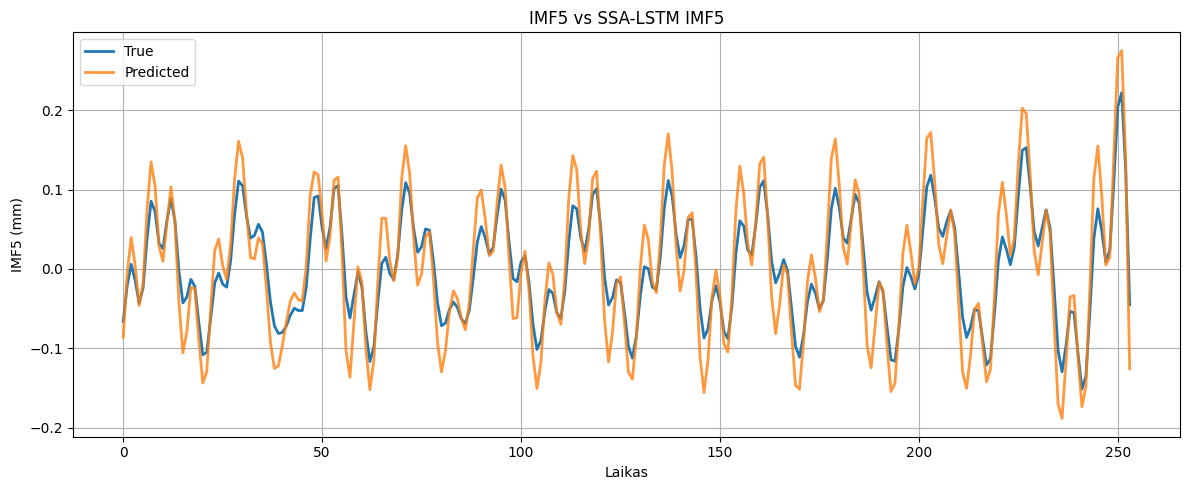

In [234]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF5 vs SSA-LSTM IMF5")
plt.xlabel("Laikas")
plt.ylabel("IMF5 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF6

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

In [294]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=14,

    module__hidden_dim=128,
    module__num_layers=1,
    module__dropout=0.1,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [295]:
pipeline.fit(X_train_IMF6.values, y_train['IMF6'].values)
pred = pipeline.predict(X_test_IMF6.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0071        0.0033     +  0.2845
      2        0.0015        0.0012     +  0.1247
      3        0.0007        0.0004     +  0.1184
      4        0.0004        0.0003     +  0.1249
      5        0.0003        0.0002     +  0.1159
      6        0.0002        0.0002     +  0.1163
      7        0.0002        0.0001     +  0.1278
      8        0.0001        0.0001     +  0.1265
      9        0.0001        0.0001        0.1437
     10        0.0001        0.0001     +  0.1391
     11        0.0001        0.0001        0.1357
     12        0.0001        0.0001     +  0.1366
     13        0.0001        0.0001        0.1428
     14        0.0001        0.0001        0.1196
     15        0.0001        0.0001        0.1215
     16        0.0001        0.0001        0.1191
     17        0.0001        0.0001        0.1193
     18        0.0001        0.0001        0.1248


In [293]:
param_grid = {
    'window_size': [14],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2],
    'lr': [0.001, 0.01],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF6.values, y_train['IMF6'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF6.values)

Fitting 2 folds for each of 48 candidates, totalling 96 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0040        0.0036     +  0.2038
      2        0.0015        0.0021     +  0.1366
      3        0.0018        0.0027        0.1323
      4        0.0015        0.0010     +  0.1514
      5        0.0005        0.0006     +  0.1743
      6        0.0003        0.0005     +  0.1455
      7        0.0003        0.0005     +  0.1355
      8        0.0002        0.0004     +  0.1360
      9        0.0002        0.0004     +  0.1456
     10        0.0002        0.0004     +  0.1295
     11        0.0002        0.0003     +  0.1450
     12        0.0001        0.0003     +  0.1534
     13        0.0001        0.0003        0.1447
     14        0.0001        0.0003     +  0.1370
     15        0.0001        0.0003     +  0.1518
     16        0.0002        0.0005        0.1525
     17        0.0004        0.0010    

In [298]:
y_true = y_test['IMF6'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[14:]
y_pred = np.array(pred).reshape(-1)[:]*-0.7

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF6 = y_true
y_pred_IMF6 = y_pred

RMSE:     0.2903
MAE:      0.2376
R2:       -1.7246
Spearman: 0.3950


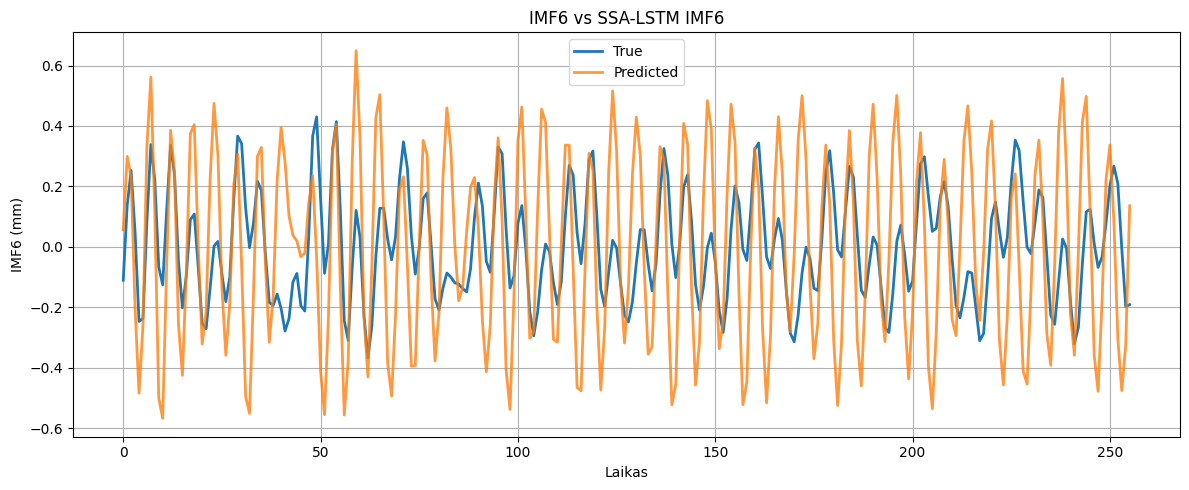

In [299]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF6 vs SSA-LSTM IMF6")
plt.xlabel("Laikas")
plt.ylabel("IMF6 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF7

{'batch_size': 32, 'lr': 0.01, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

In [301]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=14,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.1,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.01,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [302]:
pipeline.fit(X_train_IMF7.values, y_train['IMF7'].values)
pred = pipeline.predict(X_test_IMF7.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0046        0.0027     +  0.4448
      2        0.0029        0.0028        0.2581
      3        0.0023        0.0008     +  0.2506
      4        0.0013        0.0019        0.2618
      5        0.0016        0.0019        0.2696
      6        0.0018        0.0030        0.2637
      7        0.0020        0.0018        0.2704
      8        0.0012        0.0037        0.3417
      9        0.0015        0.0008     +  0.2805
     10        0.0006        0.0004     +  0.2666
     11        0.0008        0.0021        0.2837
     12        0.0011        0.0005        0.2721
     13        0.0004        0.0005        0.2564
     14        0.0005        0.0003     +  0.2707
     15        0.0004        0.0007        0.2631
     16        0.0005        0.0003        0.2700
     17        0.0002        0.0005        0.2724
     18        0.0002        0.0003     +  0.2626


In [300]:
param_grid = {
    'window_size': [14],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2],
    'lr': [0.001, 0.01],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF7.values, y_train['IMF7'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF7.values)

Fitting 2 folds for each of 48 candidates, totalling 96 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0032        0.0025     +  0.1806
      2        0.0021        0.0021     +  0.1972
      3        0.0022        0.0019     +  0.1380
      4        0.0017        0.0014     +  0.1339
      5        0.0009        0.0018        0.1550
      6        0.0008        0.0018        0.1529
      7        0.0005        0.0012     +  0.1373
      8        0.0004        0.0011     +  0.1302
      9        0.0004        0.0013        0.1400
     10        0.0005        0.0011     +  0.1506
     11        0.0003        0.0012        0.1498
     12        0.0004        0.0019        0.1511
     13        0.0004        0.0014        0.1485
     14        0.0006        0.0013        0.2731
     15        0.0004        0.0011     +  0.2016
     16        0.0003        0.0011        0.1799
     17        0.0002        0.0011    

In [307]:
y_true = y_test['IMF7'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[14:-2]
y_pred = np.array(pred).reshape(-1)[2:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF7 = y_true
y_pred_IMF7 = y_pred

RMSE:     0.0656
MAE:      0.0548
R2:       0.5783
Spearman: 0.8426


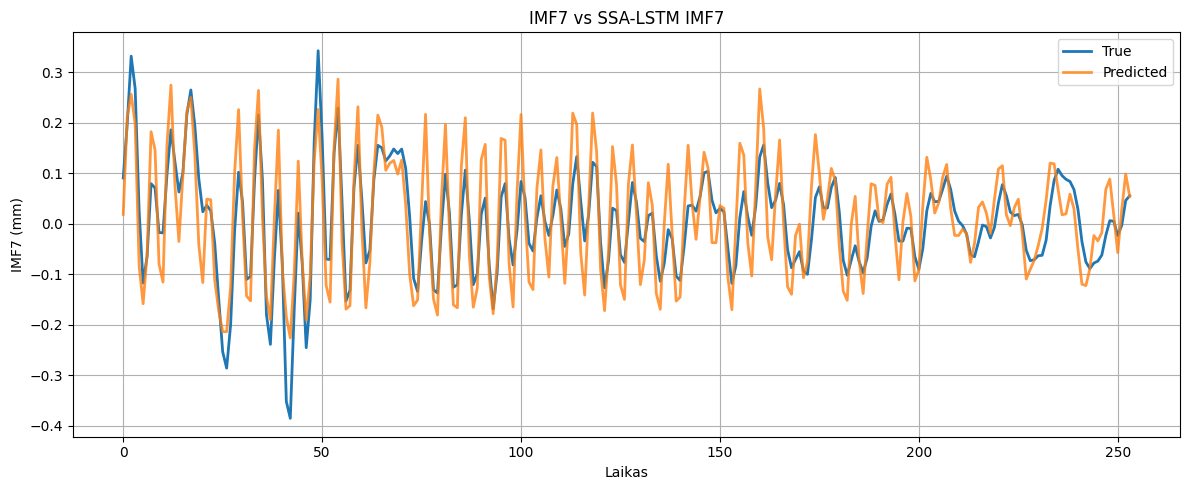

In [308]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF7 vs SSA-LSTM IMF7")
plt.xlabel("Laikas")
plt.ylabel("IMF7 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF8

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

In [311]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=14,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.1,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [312]:
pipeline.fit(X_train_IMF8.values, y_train['IMF8'].values)
pred = pipeline.predict(X_test_IMF8.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0556        0.0597     +  0.4681
      2        0.0513        0.0527     +  0.2507
      3        0.0459        0.0564        0.2574
      4        0.0418        0.0567        0.2617
      5        0.0396        0.0584        0.2590
      6        0.0388        0.0558        0.2766
      7        0.0348        0.0567        0.2777
      8        0.0327        0.0551        0.2647
      9        0.0310        0.0586        0.2571
     10        0.0276        0.0576        0.2648
     11        0.0264        0.0577        0.2528
     12        0.0268        0.0562        0.2634
     13        0.0248        0.0628        0.2689
     14        0.0240        0.0610        0.2656
     15        0.0221        0.0613        0.2717
     16        0.0220        0.0702        0.2762
Stopping since valid_loss has not improved in the last 15 epochs.


In [310]:
param_grid = {
    'window_size': [14],
    'module__hidden_dim': [32, 64, 128],
    'module__num_layers': [1, 2],
    'lr': [0.001, 0.01],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [8, 16, 32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF8.values, y_train['IMF8'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF8.values)

Fitting 2 folds for each of 96 candidates, totalling 192 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0558        0.0676     +  0.3855
      2        0.0508        0.0668     +  0.3334
      3        0.0455        0.0681        0.2855
      4        0.0407        0.0700        0.2796
      5        0.0392        0.0845        0.3201
      6        0.0349        0.0954        0.3562
      7        0.0369        0.0663     +  0.3471
      8        0.0344        0.0820        0.2915
      9        0.0316        0.0716        0.3137
     10        0.0247        0.0828        0.4366
     11        0.0213        0.0897        0.2978
     12        0.0214        0.0889        0.3324
     13        0.0201        0.0861        0.3360
     14        0.0224        0.0748        0.2817
     15        0.0198        0.0903        0.2685
     16        0.0164        0.0814        0.2732
     17        0.0133        0.0839   

In [319]:
y_true = y_test['IMF8'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[14:-2]
y_pred = np.array(pred).reshape(-1)[2:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF8 = y_true
y_pred_IMF8 = y_pred

RMSE:     0.4542
MAE:      0.3575
R2:       -0.0487
Spearman: 0.1357


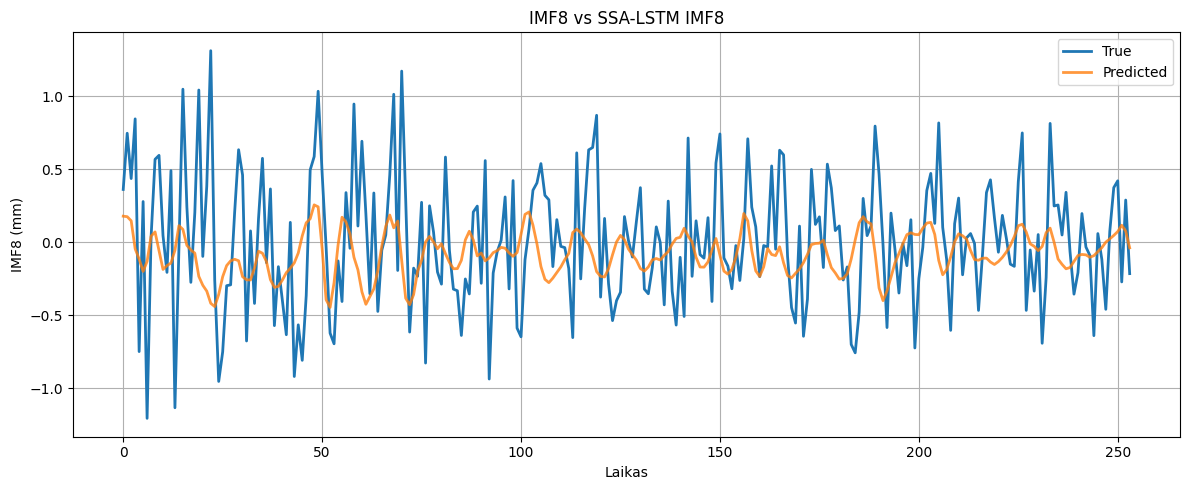

In [320]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True",      linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2, alpha=0.8)
plt.title("IMF8 vs SSA-LSTM IMF8")
plt.xlabel("Laikas")
plt.ylabel("IMF8 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### SSA-LSTM rezultatai

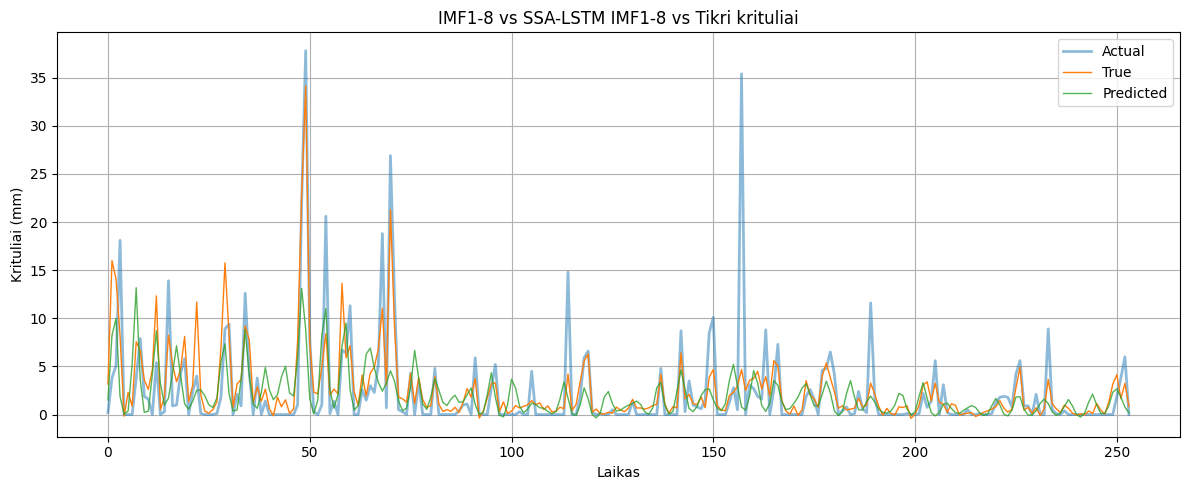

In [349]:
y_true_final = np.expm1(y_true_IMF1[:-2] + y_true_IMF2[:-2] + y_true_IMF3[:-2] + y_true_IMF4[:-1] + y_true_IMF5 + y_true_IMF6[:-2] + y_true_IMF7 + y_true_IMF8)
y_pred_final = np.expm1(y_pred_IMF1[:-2] + y_pred_IMF2[:-2] + y_pred_IMF3[:-2] + y_pred_IMF4[:-1] + y_pred_IMF5 + y_pred_IMF6[:-2] + y_pred_IMF7 + y_pred_IMF8)
y_actual_precipitation = X_test['missforest_precipitation'][15:-1].values

plt.figure(figsize=(12, 5))
plt.plot(y_actual_precipitation, label="Actual", linewidth=2, alpha=0.5)
plt.plot(y_true_final, label="True",      linewidth=1)
plt.plot(y_pred_final, label="Predicted", linewidth=1, alpha=0.8)
plt.title("IMF1-8 vs SSA-LSTM IMF1-8 vs Tikri krituliai")
plt.xlabel("Laikas")
plt.ylabel("Krituliai (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [339]:
rmse = np.sqrt(mean_squared_error(y_true_final, y_pred_final))
mae  = mean_absolute_error(y_true_final, y_pred_final)
r2   = r2_score(y_true_final, y_pred_final)
spearman_corr, _ = spearmanr(y_true_final, y_pred_final)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     2.9678
MAE:      1.6384
R2:       0.4101
Spearman: 0.5859


In [350]:
rmse = np.sqrt(mean_squared_error(y_actual_precipitation, y_pred_final))
mae  = mean_absolute_error(y_actual_precipitation, y_pred_final)
r2   = r2_score(y_actual_precipitation, y_pred_final)
spearman_corr, _ = spearmanr(y_actual_precipitation, y_pred_final)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     4.5603
MAE:      2.3897
R2:       0.1644
Spearman: 0.4237
